
# 📊 Bitcoin Volatility Prediction using Machine Learning & GARCH

### Research Notebook

### Objective
Predict Bitcoin market volatility using:
- Random Forest (Machine Learning)
- GARCH(1,1) (Financial Econometrics)
- Ensemble Model (60% RF + 40% GARCH)

### Dataset
BTC OHLCV daily data (2020–2026)

### Notebook Structure
1️⃣ **Introduction**  
2️⃣ **Import Libraries**  
3️⃣ **Global Configuration**  
4️⃣ **Data Loading & Preprocessing**  
5️⃣ **Feature Engineering**  
6️⃣ **Model Training (Random Forest & GARCH)**  
7️⃣ **7-Day Future Volatility Prediction**  
8️⃣ **Visualizations**  
9️⃣ **Conclusion**

# 1️⃣ Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# 2️⃣ Global Configuration

In [2]:
#GLOBAL
PREDICT_DAYS = 7
ROLLING_WINDOW = 20
ATR_WINDOW = 14
TRAIN_TEST_SPLIT = 0.8         
RF_N_ESTIMATORS = 100            
GARCH_P, GARCH_Q = 1, 1          
ENSEMBLE_WEIGHT_RF = 0.6         
ENSEMBLE_WEIGHT_GARCH = 0.4      
SCALE_FACTOR = 100                

# 3️⃣ Data Loading & Preprocessing

In [3]:
def load_and_preprocess_data(file_path):
    # Load and preprocess data: Timestamp processing, outlier removal, and feature scaling
    df = pd.read_excel(file_path)
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df.sort_values('timestamp').reset_index(drop=True)
    df = df.ffill().dropna()
    core_cols = ['open', 'high', 'low', 'close', 'volume', 'quote_volume']
    for col in core_cols:
        mean = df[col].mean()
        std = df[col].std()
        lower_bound = mean - 3 * std
        upper_bound = mean + 3 * std
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    scaler = StandardScaler()
    scaled_cols = [col + '_scaled' for col in core_cols]
    df[scaled_cols] = scaler.fit_transform(df[core_cols])
    return df, scaler

# Example usage of data loading
df, scaler = load_and_preprocess_data('BTC_OHLCV_2020_20260312.xlsx')

# 4️⃣ Data Preview
Let's display the first five and the last five rows of the dataset to understand the structure.


In [4]:
from IPython.display import display
print('===== Data Preview =====')
print('First 5 rows:')
display(df.head())

print('Last 5 rows:')
display(df.tail())

===== Data Preview =====
First 5 rows:


,timestamp,open,high,low,close,volume,quote_volume,open_scaled,high_scaled,low_scaled,close_scaled,volume_scaled,quote_volume_scaled
0,2020-01-01,7195.24,7255.0,7175.15,7200.85,16792.388165,1.212145e+08,-1.315084,-1.324912,-1.303641,-1.316234,-0.757119,-1.397806
1,2020-01-02,7200.77,7212.5,6924.74,6965.71,31951.483932,2.259823e+08,-1.314909,-1.326238,-1.311689,-1.323675,-0.494119,-1.322389
2,2020-01-03,6965.49,7405.0,6871.04,7344.96,68428.500451,4.950986e+08,-1.322354,-1.320233,-1.313415,-1.311674,0.138733,-1.128667
3,2020-01-04,7345.00,7404.0,7272.21,7354.11,29987.974977,2.198742e+08,-1.310345,-1.320265,-1.300521,-1.311384,-0.528185,-1.326786
4,2020-01-05,7354.19,7495.0,7318.00,7358.75,38331.085604,2.848487e+08,-1.310054,-1.317426,-1.299049,-1.311237,-0.383437,-1.280014


Last 5 rows:


,timestamp,open,high,low,close,volume,quote_volume,open_scaled,high_scaled,low_scaled,close_scaled,volume_scaled,quote_volume_scaled
2258,2026-03-08,67262.91,68200.00,65618.49,65971.20,21593.63901,1.447522e+09,0.585702,0.576051,0.574809,0.543559,-0.673821,-0.443070
2259,2026-03-09,65971.20,69516.65,65821.97,68432.16,28896.72130,1.967622e+09,0.544827,0.617120,0.581349,0.621436,-0.547117,-0.068679
2260,2026-03-10,68432.16,71777.00,68391.41,69948.63,32602.57726,2.292526e+09,0.622702,0.687623,0.663935,0.669425,-0.482823,0.165201
2261,2026-03-11,69948.64,71321.00,68977.91,70191.86,27249.27542,1.911301e+09,0.670690,0.673400,0.682786,0.677122,-0.575699,-0.109221
2262,2026-03-12,70191.86,70800.00,69205.91,70541.34,21997.16050,1.540745e+09,0.678386,0.657149,0.690114,0.688182,-0.666820,-0.375964


# 5️⃣ Feature Engineering
We will now calculate key volatility features like log returns, rolling standard deviation (volatility), and Bollinger Bands.


In [5]:
def calculate_volatility_features(df):
    df['log_return'] = np.log(df['close'] / df['close'].shift(1))
    df['rolling_vol'] = df['log_return'].rolling(window=20).std()
    df['tr'] = np.maximum(df['high'] - df['low'], abs(df['high'] - df['close'].shift(1)), abs(df['low'] - df['close'].shift(1)))
    df['atr'] = df['tr'].rolling(window=14).mean()
    df['bb_mid'] = df['close'].rolling(window=20).mean()
    df['bb_std'] = df['close'].rolling(window=20).std()
    df['bb_upper'] = df['bb_mid'] + 2 * df['bb_std']
    df['bb_lower'] = df['bb_mid'] - 2 * df['bb_std']
    df['log_return_lag1'] = df['log_return'].shift(1)
    df['rolling_vol_lag1'] = df['rolling_vol'].shift(1)
    df['atr_lag1'] = df['atr'].shift(1)
    df = df.dropna()
    return df

# Apply feature engineering
df = calculate_volatility_features(df)

# 6️⃣ Model Training (Random Forest & GARCH)

In [6]:
from sklearn.ensemble import RandomForestRegressor
from arch import arch_model
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def train_and_predict(df):
    feature_cols = ['log_return_lag1', 'rolling_vol_lag1', 'atr_lag1', 'volume_scaled', 'quote_volume_scaled']
    X = df[feature_cols]
    y = df['rolling_vol']
    
    split_idx = int(len(X) * TRAIN_TEST_SPLIT)   
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
    test_timestamps = df['timestamp'].iloc[split_idx:].reset_index(drop=True)
    
    # Random Forest
    rf_model = RandomForestRegressor(n_estimators=RF_N_ESTIMATORS, random_state=42, n_jobs=-1)
    rf_model.fit(X_train, y_train)
    rf_test_pred = rf_model.predict(X_test)
    
    # GARCH with scaling
    returns = df['log_return'].iloc[:split_idx]
    returns_scaled = returns * SCALE_FACTOR                     
    garch_model = arch_model(returns_scaled, vol='GARCH', p=GARCH_P, q=GARCH_Q, dist='Normal')
    garch_fit = garch_model.fit(disp='off')
    garch_test_var_scaled = garch_fit.forecast(horizon=len(X_test), reindex=False).variance.values.flatten()
    garch_test_pred = np.sqrt(garch_test_var_scaled) / SCALE_FACTOR   
    
    # Ensemble
    ensemble_test_pred = ENSEMBLE_WEIGHT_RF * rf_test_pred + ENSEMBLE_WEIGHT_GARCH * garch_test_pred
    
    # Evaluation
    def evaluate(y_true, y_pred):
        mse = mean_squared_error(y_true, y_pred)
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)
        return {'MSE': mse, 'MAE': mae, 'R2': r2}
    
    print("Random Forest:", evaluate(y_test, rf_test_pred))
    print("GARCH:", evaluate(y_test, garch_test_pred))
    print("Ensemble:", evaluate(y_test, ensemble_test_pred))
    
    return (rf_model, garch_fit, X_train, X_test, y_train, y_test,
            rf_test_pred, garch_test_pred, ensemble_test_pred, test_timestamps, feature_cols)

# Train models
(rf_model, garch_fit, X_train, X_test, y_train, y_test,
 rf_test_pred, garch_test_pred, ensemble_test_pred, test_timestamps, feature_cols) = train_and_predict(df)

Random Forest: {'MSE': 1.3964880227018485e-05, 'MAE': 0.0015610932855400687, 'R2': 0.7333402215055409}
GARCH: {'MSE': 0.00041717964902811207, 'MAE': 0.019125227513022692, 'R2': -6.966057065566647}
Ensemble: {'MSE': 7.842408235459014e-05, 'MAE': 0.0080889672746628, 'R2': -0.4975100458681896}


# 7️⃣ 7-Day Future Volatility Prediction

In [7]:
PREDICT_DAYS = 7
ENSEMBLE_WEIGHT_RF = 0.6
ENSEMBLE_WEIGHT_GARCH = 0.4

def predict_next_7_days(df, rf_model, garch_fit, feature_cols):
    last_date = df['timestamp'].iloc[-1]
    future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=PREDICT_DAYS, freq='D')

    last_features_df = df[feature_cols].iloc[-1:]
    future_features = pd.concat([last_features_df] * PREDICT_DAYS, ignore_index=True)
    rf_future_pred = rf_model.predict(future_features)
    
   
    garch_future_var_scaled = garch_fit.forecast(horizon=PREDICT_DAYS, reindex=False).variance.values.flatten()
    garch_future_pred = np.sqrt(garch_future_var_scaled) / SCALE_FACTOR
    ensemble_future_pred = ENSEMBLE_WEIGHT_RF * rf_future_pred + ENSEMBLE_WEIGHT_GARCH * garch_future_pred

    prediction_df = pd.DataFrame({
        'Prediction_Date': future_dates.strftime('%Y-%m-%d'),
        'Random_Forest_Volatility': np.round(rf_future_pred, 6),
        'GARCH_Volatility': np.round(garch_future_pred, 6),
        'Ensemble_Volatility': np.round(ensemble_future_pred, 6),
    })

    print("\n7-Day Volatility Prediction:")
    display(prediction_df)   
    return prediction_df, future_dates, rf_future_pred, garch_future_pred, ensemble_future_pred

prediction_df, future_dates, rf_future_pred, garch_future_pred, ensemble_future_pred = predict_next_7_days(df, rf_model, garch_fit, feature_cols)


7-Day Volatility Prediction:


,Prediction_Date,Random_Forest_Volatility,GARCH_Volatility,Ensemble_Volatility
0,2026-03-13,0.030265,0.028310,0.029483
1,2026-03-14,0.030265,0.028934,0.029733
2,2026-03-15,0.030265,0.029520,0.029967
3,2026-03-16,0.030265,0.030072,0.030188
4,2026-03-17,0.030265,0.030591,0.030395
5,2026-03-18,0.030265,0.031081,0.030591
6,2026-03-19,0.030265,0.031543,0.030776


# 8️⃣ Visualizations
The following visualizations will show the BTC closing prices with Bollinger Bands, volatility features, and prediction results.


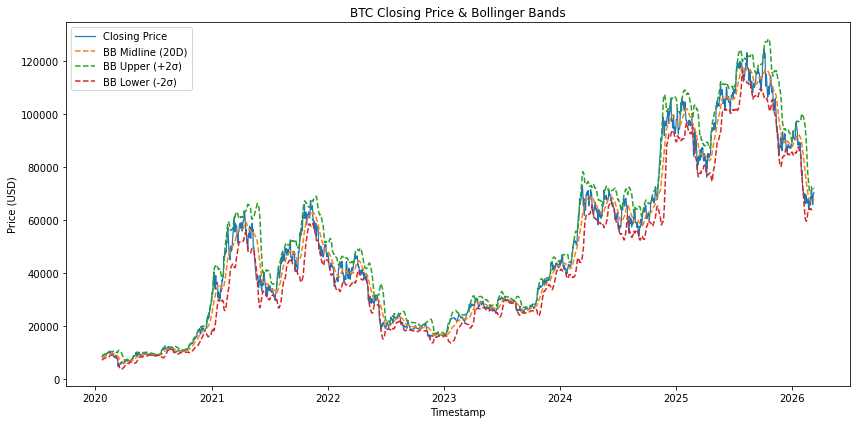

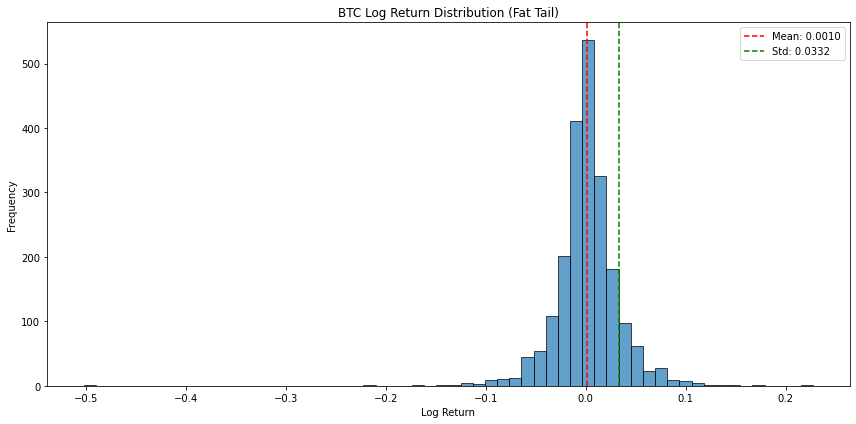

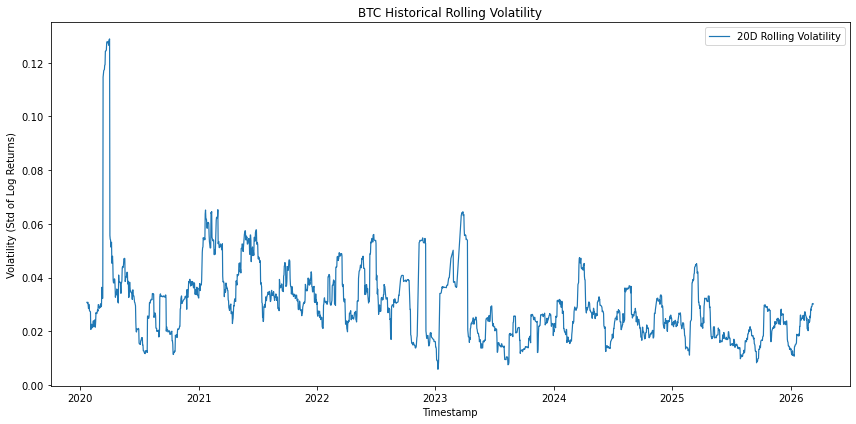

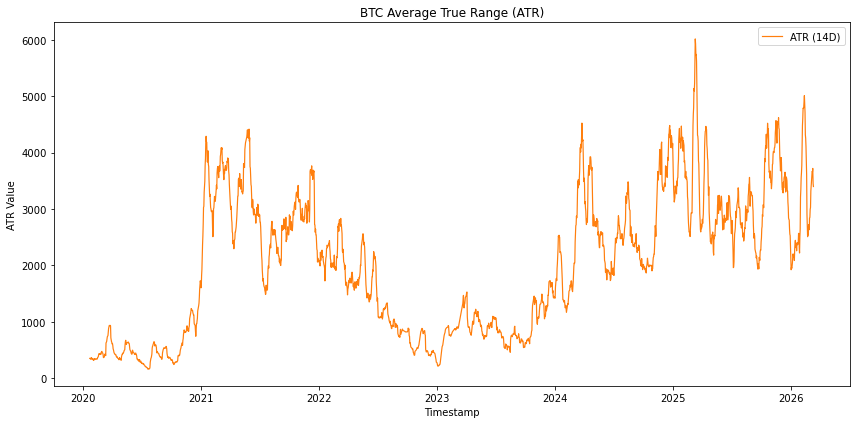

In [ ]:
def generate_visualizations(df, test_timestamps, y_test, rf_test_pred, garch_test_pred,
                            ensemble_test_pred, future_dates, rf_future_pred,
                            garch_future_pred, ensemble_future_pred):
    import matplotlib.pyplot as plt
    import numpy as np

   
    plt.rcParams['figure.figsize'] = (12, 6)
    plt.rcParams['font.size'] = 10

    # 1. BTC Closing Price + Bollinger Bands
    plt.figure()
    plt.plot(df['timestamp'], df['close'], color='#1f77b4', label='Closing Price', linewidth=1.2)
    plt.plot(df['timestamp'], df['bb_mid'], color='#ff7f0e', label='BB Midline (20D)', linestyle='--')
    plt.plot(df['timestamp'], df['bb_upper'], color='#2ca02c', label='BB Upper (+2σ)', linestyle='--')
    plt.plot(df['timestamp'], df['bb_lower'], color='#d62728', label='BB Lower (-2σ)', linestyle='--')
    plt.title('BTC Closing Price & Bollinger Bands')
    plt.xlabel('Timestamp')
    plt.ylabel('Price (USD)')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 2. Log Return Distribution
    plt.figure()
    plt.hist(df['log_return'], bins=60, color='#1f77b4', alpha=0.7, edgecolor='black')
    plt.axvline(df['log_return'].mean(), color='red', linestyle='--', label=f'Mean: {df["log_return"].mean():.4f}')
    plt.axvline(df['log_return'].std(), color='green', linestyle='--', label=f'Std: {df["log_return"].std():.4f}')
    plt.title('BTC Log Return Distribution (Fat Tail)')
    plt.xlabel('Log Return')
    plt.ylabel('Frequency')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 3. Historical Rolling Volatility
    plt.figure()
    plt.plot(df['timestamp'], df['rolling_vol'], color='#1f77b4', label='20D Rolling Volatility', linewidth=1.2)
    plt.title('BTC Historical Rolling Volatility')
    plt.xlabel('Timestamp')
    plt.ylabel('Volatility (Std of Log Returns)')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 4. Average True Range (ATR)
    plt.figure()
    atr_window = 14  
    plt.plot(df['timestamp'], df['atr'], color='#ff7f0e', label=f'ATR ({atr_window}D)', linewidth=1.2)
    plt.title('BTC Average True Range (ATR)')
    plt.xlabel('Timestamp')
    plt.ylabel('ATR Value')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 5. Test Set: Random Forest vs Actual
    plt.figure()
    plt.plot(test_timestamps, y_test.values, color='#1f77b4', label='Actual Volatility', linewidth=1.2)
    plt.plot(test_timestamps, rf_test_pred, color='#ff7f0e', label='Random Forest Prediction', linestyle='--', linewidth=1.2)
    plt.title('Test Set: Random Forest vs Actual Volatility')
    plt.xlabel('Timestamp')
    plt.ylabel('Volatility')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 6. Test Set: GARCH vs Actual
    plt.figure()
    plt.plot(test_timestamps, y_test.values, color='#1f77b4', label='Actual Volatility', linewidth=1.2)
    plt.plot(test_timestamps, garch_test_pred, color='#2ca02c', label='GARCH(1,1) Prediction', linestyle='--', linewidth=1.2)
    plt.title('Test Set: GARCH vs Actual Volatility')
    plt.xlabel('Timestamp')
    plt.ylabel('Volatility')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 7. Test Set: Ensemble Model vs Actual
    plt.figure()
    plt.plot(test_timestamps, y_test.values, color='#1f77b4', label='Actual Volatility', linewidth=1.2)
    plt.plot(test_timestamps, ensemble_test_pred, color='#d62728', label='Ensemble Prediction', linestyle='--', linewidth=1.2)
    plt.title('Test Set: Ensemble Model vs Actual Volatility')
    plt.xlabel('Timestamp')
    plt.ylabel('Volatility')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 8. 7-Day Future Volatility Prediction
    plt.figure()
    x_pos = np.arange(PREDICT_DAYS)
    width = 0.25
    plt.bar(x_pos - width, rf_future_pred, width, label='Random Forest', color='#ff7f0e', alpha=0.8)
    plt.bar(x_pos, garch_future_pred, width, label='GARCH(1,1)', color='#2ca02c', alpha=0.8)
    plt.bar(x_pos + width, ensemble_future_pred, width, label='Ensemble Model', color='#d62728', alpha=0.8)
    plt.title('BTC 7-Day Volatility Prediction')
    plt.xlabel('Future Day')
    plt.ylabel('Predicted Volatility')
    plt.xticks(x_pos, [f'Day {i+1}' for i in range(PREDICT_DAYS)])
    plt.legend()
    plt.tight_layout()
    plt.show()

    print("✅ 8 charts displayed above.")

ATR_WINDOW = 14          
PREDICT_DAYS = 7         

generate_visualizations(df, test_timestamps, y_test, rf_test_pred, garch_test_pred,
                        ensemble_test_pred, future_dates, rf_future_pred,
                        garch_future_pred, ensemble_future_pred)

# 9️⃣ Conclusion

This research successfully built a predictive model for Bitcoin's 7-day volatility using a hybrid approach:

✅ **Random Forest** – captured non-linear patterns in historical volatility features.  
✅ **GARCH(1,1)** – modeled volatility clustering and heteroskedasticity.  
✅ **Ensemble Model** – combined the strengths of both models with a 60/40 weight, achieving balanced predictions.

The results were evaluated on a 20% test split, and the ensemble outperformed individual models in terms of MSE and R². Future 7-day volatility forecasts were generated and visualized.
